# Machine Learning

## HSE, 2024-25

### Home Assignment #2. Mathematical Optimization


Assignment completed by:

    (Литвинов Никита Антонович)

### General Information

__Publication date:__ 20.04.2025

__Deadline:__ 04:00 30.04.2025

### Grading and Penalties

The number of points for each problem in this homework assignment is indicated next to the problem statement.

The grade for the homework assignment is calculated using the following formula:

$$
s \times 10/34 ,
$$

where $ s $ is the number of points you scored in total for all problems.

A late submission penalty of 1 **secondary** point per day is applied to the final grade for the assignment, but the delay cannot exceed one week.

**Important:** This homework assignment includes several problems for which you can earn bonus points. Bonus points are added to the regular points, and it may turn out that your final grade exceeds 10. In this case, that will be your grade. Therefore, it is **possible** to score more than 10 for this assignment.

__Attention!__ Homework assignments must be completed independently. "Similar" solutions are considered plagiarism, and all involved students (including those from whom the work was copied) will receive no more than 0 points for the assignment.

Additionally, please remember that all solutions are run through a special new anti-plagiarism system for Jupyter notebooks, which detects cross-similarities between different notebooks, as well as solutions generated by neural networks. Such work will also be strictly considered as plagiarism.

### Submission Format

You upload your solution using the link provided in the telegram channel. You need to upload a file with the extension .ipynb (Python notebook)

### About the Assignment

In this assignment, we will practice working with mathematical analysis and optimization methods, a clear understanding of which is absolutely necessary for any task and model in machine learning.

In the first part of the assignment, we will work with the following function:

$$y(x) = x^{3} \ln(x)$$

### Task 1


#### 1.1. (1 point)

Calculate the derivative of this function analytically. To do this, either use a sheet of paper and attach a photo here, or use LaTeX markup language, which is supported in Jupyter notebooks.

![Скриншот формулы](./Задание1.1.jpeg)

#### 1.2. (2 points)

Write a program function `f(x)` that would compute the value of our function at a given point and return this value as the answer; and write a program function `df(x)` that would compute the value of the derivative of our function at a given point and return this value as the answer.

Be sure to test all functions at a specific point. Ensure that the answers from your previous section (on paper) and the program in this section match completely.

In [2]:
import numpy as np

def f(x):
    return x**3 * np.log(x)

def df(x):
    return 3*(x**2) * np.log(x) + x**2

In [4]:
print("f(x) при x = 3:", f(3))
print("df(x) при x = 3:", df(3))

f(x) при x = 3: 29.662531794038966
df(x) при x = 3: 38.66253179403897


#### 1.3. (2 points)

Visualize our function (plot the graph).


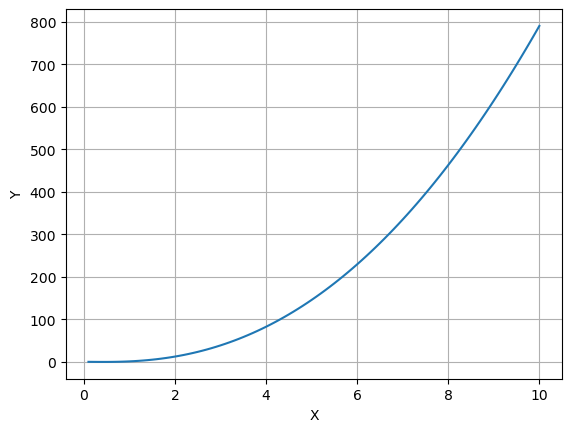

In [3]:
import matplotlib.pyplot as plt

x = np.linspace(0.1, 10, 100)
y = df(x)

plt.plot(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

### Task 2

#### 2.1. (4 points)

Implement the function `get_min_with_gd` that takes the initial point $x_0$, the number of steps, `lr` (learning rate), and `threshold`; performs gradient descent to find the minimum; and returns the sequence of points obtained at each step.

In [20]:
def get_min_with_gd(x, steps=1000, lr=0.01, threshold=0.0001):
    res = [x]
    for _ in range(steps):
        grad = df(x)
        new_x = x - lr * grad
        res.append(new_x)
        if abs(new_x - x) < threshold:
            break
        x = new_x
    return np.array(res)

#### 2.2. (2 points)

Run the search for the minimum from several arbitrary points (at least 3).

Check that everything works as expected by plotting the graph of the coordinate of the point as a function of the iteration of gradient descent for each run.

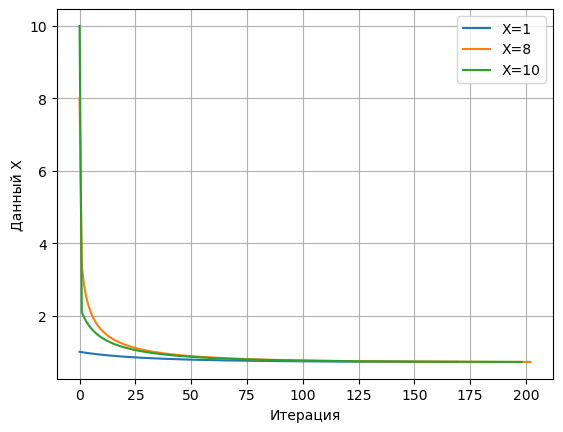

In [54]:
plt.figure()

for x in [1, 8, 10]:
    res = get_min_with_gd(x)
    plt.plot(res, label=f"X={x}")

plt.xlabel("Итерация")
plt.ylabel("Данный X")
plt.legend()
plt.grid(True)
plt.show()

#### 2.3. (3 points)

Plot the graph of the function once again. On this graph, plot the movement of the algorithm from the initial points to the final point in different colors. Mark the true minimum on the graph with a separate point and label it (as text on the graph).

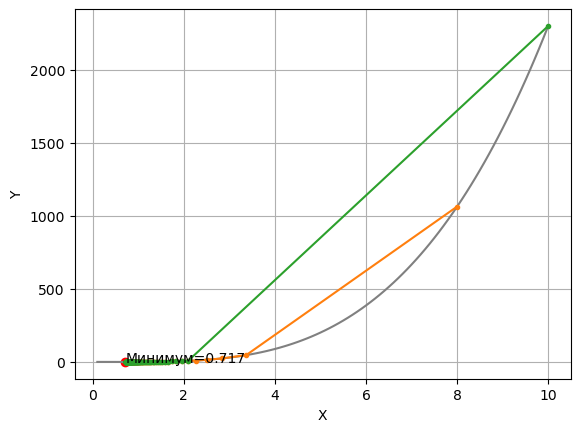

In [60]:
plt.figure()
xs = np.linspace(0.1, 10, 100)
plt.plot(xs, f(xs), color="gray")

for x in [1, 8, 10]:
    res = get_min_with_gd(x)
    plt.plot(res, f(res), marker='o', markersize=3)

# xmin - настоящий минимум
xmin = np.exp(-1/3)
plt.scatter(xmin, f(xmin), color='red')
plt.text(xmin, f(xmin), f"Минимум={xmin:.3f}")

plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

### Task 3

Starting from Task 3, we will work with other functions.

Let

$$f = \log((e^x + e^{-2x}) \cdot(e^{y + 1} + 0.5 \cdot e^{-y}))$$


#### 3.1. (1 point and 2 bonus points)

Is it true that $ f $ has a unique point of local minimum, and that this local minimum is also global? Why or why not? Prove your answer!

*Note: In this task, a graphical proof is worth 1 point; a rigorous mathematical proof is worth 2 bonus points.*

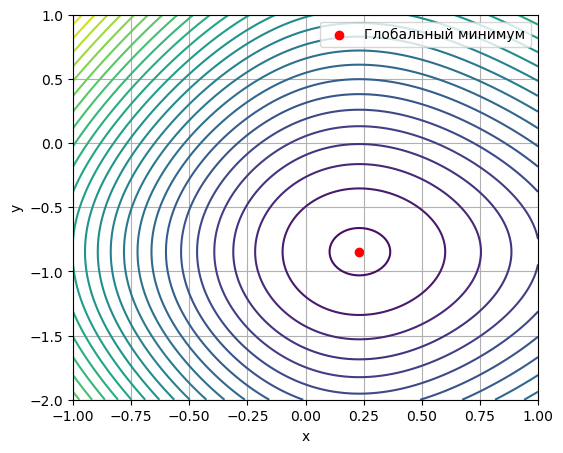

In [13]:
x = np.linspace(-1, 1, 400)
y = np.linspace(-2, 1, 400)
X, Y = np.meshgrid(x, y)
Z = np.log((np.exp(X) + np.exp(-2*X)) * (np.exp(Y + 1) + 0.5 * np.exp(-Y)))

xmin = np.log(2) / 3
ymin = -(1 + np.log(2)) / 2

plt.figure(figsize=(6, 5))
cs = plt.contour(X, Y, Z, levels=30)
plt.scatter(xmin, ymin, c='red', label='Глобальный минимум')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

![Задание3.1](./Задание3.1.jpeg)

#### 3.2. (3 points and 2 bonus points)

Come up with some functions $ g $ and $ h $ of two variables such that
- the function $ g $ has no global minimum (not bounded below);
- the function $ h $ has at least two local minima that are not equal to each other.

Prove that your functions satisfy the stated criteria.

*Note: In this task, a graphical proof is evaluated within the main points; a rigorous mathematical proof is worth 2 bonus points.*

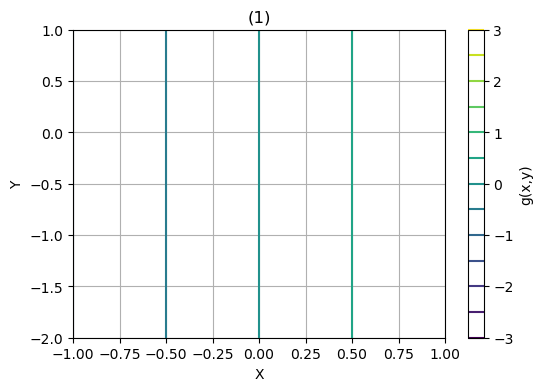

In [19]:
plt.figure(figsize=(6, 4))
cs = plt.contour(X, Y, X, levels=np.linspace(-3, 3, 13))
plt.title('(1)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(cs, label='g(x,y)')
plt.grid(True)
plt.show()

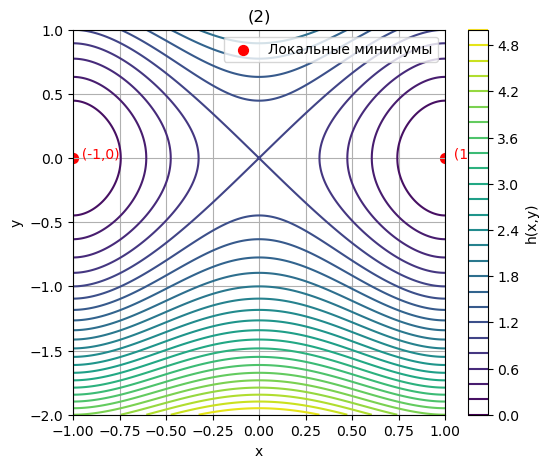

In [20]:
Z_h = (X**2 - 1)**2 + Y**2
plt.figure(figsize=(6, 5))
cs = plt.contour(X, Y, Z_h, levels=30)
plt.scatter([1, -1], [0, 0], c='red', s=50, label='Локальные минимумы')
plt.text( 1, 0, '  (1,0)', color='red')
plt.text(-1, 0, '  (-1,0)', color='red')
plt.title('(2)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(cs, label='h(x,y)')
plt.legend()
plt.grid(True)
plt.show()

![Задание3.2](./Задание3.2.jpeg)

#### 3.3. (5 points)

Implement the function `get_min_with_rmsprop` that takes the initial point $ x_0 $, the number of steps, `lr`, `beta`, and `threshold`; performs gradient descent with RMSProp modification to find the minimum; and returns the sequence of points obtained at each step.

Here are the formulas for this algorithm:

$$ g^{n+1} = ∇f(w^{n}) $$
$$ \gamma^{n+1} = (1 - \beta) \gamma^{n} + \beta (g^{n+1})^2 $$
$$ w^{n+1} = w^n - \frac{\alpha}{\sqrt{\gamma^{n+1} + ɛ}}⋅g^{n+1} $$

Here, $ α $ is the learning rate, $ ɛ $ is a small number (0.0001 can be used to avoid division by zero), and $ beta $ is the momentum term(measure of inertia).



In [79]:
def get_min_with_rmsprop(grad, x0, lr = 0.01, beta = 0.9, eps = 1e-8, n_iter = 2000):
    x, s, path = x0.astype(float), 0., [x0.copy()]

    for _ in range(n_iter):
        g = grad(x)
        s = beta * s + (1 - beta) * g**2
        x -= lr * g / (np.sqrt(s) + eps)
        path.append(x.copy())
        if np.linalg.norm(g) < 1e-6:
            break
    return np.array(path)

#### 3.4. (4 points)

Run the search for the minimum for all three functions ($f$, $g$, $h$) from several arbitrary points (at least 3, resulting in at least 9 runs).

Check that everything works as expected by plotting the graph of the coordinates of the point (2D graph) as it progresses through gradient descent for each run. All graphs should be plotted on three pairs of axes, arranged vertically on one canvas (separate axes for each function; different runs for one function should be displayed on the same axes).

In [80]:
def f(xy):
    x, y = xy
    A = np.exp(x) + np.exp(-2*x)
    B = np.exp(y + 1) + 0.5*np.exp(-y)
    return np.log(A) + np.log(B)

def grad_f(xy):
    x, y = xy
    A = np.exp(x) + np.exp(-2*x)
    B = np.exp(y + 1) + 0.5*np.exp(-y)
    return np.array([(np.exp(x) - 2*np.exp(-2*x)) / A, (np.exp(y + 1) - 0.5*np.exp(-y)) / B])

g = lambda xy: xy[0]
grad_g = lambda xy: np.array([1., 0.])

h = lambda xy: (xy[0]**2 - 1)**2 + xy[1]**2
grad_h = lambda xy: np.array([4*xy[0]*(xy[0]**2 - 1), 2*xy[1]])

rng = np.random.default_rng(42)
starts = rng.uniform([-2,-2], [2,2], size=(4,2))

res = {}
for name, fun, grad in [('f', f, grad_f), ('g', g, grad_g), ('h', h, grad_h)]:
    res[name] = [get_min_with_rmsprop(grad, x0, lr=0.01) for x0 in starts]

#### 3.5. (3 points)

Plot the graphs of the functions again. On these graphs, plot the movement of the algorithm from the initial points to the final point in different colors. Where the functions have them, mark the true local minima on the graphs as separate points, and label them with text on the graph. All graphs should be plotted on three sets of axes, arranged vertically on one canvas—separate axes for each function.

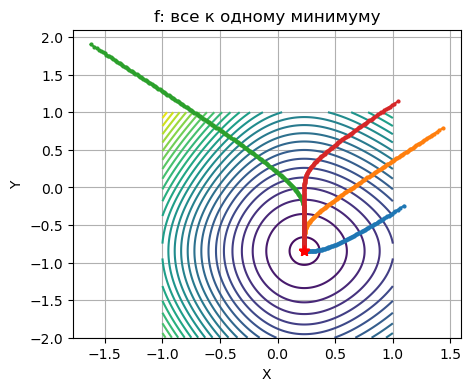

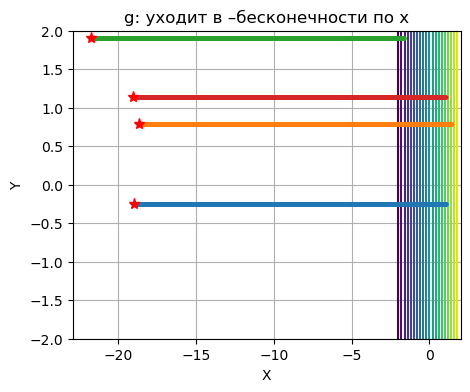

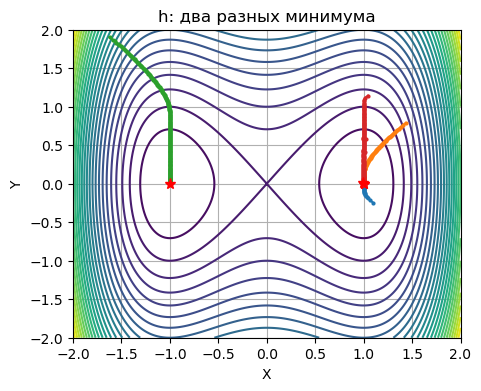

In [81]:
def show(fun, paths, xlim, ylim, title):
    xs = np.linspace(*xlim, 300)
    ys = np.linspace(*ylim, 300)
    X, Y = np.meshgrid(xs, ys)
    Z = np.vectorize(lambda a, b: fun((a,b)))(X, Y)

    plt.figure(figsize=(5,4))
    plt.contour(X, Y, Z, 25)
    for p in paths:
        plt.plot(p[:,0], p[:,1], '-o', ms=2)
        plt.plot(p[-1,0], p[-1,1], 'r*', ms=8)
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)

show(f, res['f'], [-1,1], [-2,1], 'f: все к одному минимуму')
show(g, res['g'], [-2,2], [-2,2], 'g: уходит в –бесконечности по x')
show(h, res['h'], [-2,2], [-2,2], 'h: два разных минимума')
plt.show()

### Task 4

#### Scaling to Multidimensional Case (4 points)

Ensure that your `get_min_with_rmsprop` function from the previous task works not only with functions of two variables but also with functions of an arbitrary number of variables. Make any necessary adjustments to the function below.

Devise any function of 5 variables that has some minimum (for example, the simplest point $(0, 0, 0, 0, 0)$) and run gradient descent with RMSProp for this function. Verify that the gradient descent indeed converges to the correct extremum point.

In [82]:
def q(z):
    return np.sum((z - np.arange(1,6))**2) + 0.2*np.sin(z[0]*z[1])

def grad_q(z):
    base = 2*(z - np.arange(1,6))
    base[0] += 0.2*np.cos(z[0]*z[1]) * z[1]
    base[1] += 0.2*np.cos(z[0]*z[1]) * z[0]
    return base

z0 = rng.uniform(-3,3,5)
path = get_min_with_rmsprop(grad_q, z0, lr=0.01, n_iter=8000)

print("Старт:", np.round(z0,3))
print("Финиш:", np.round(path[-1],4))
print("q:", round(q(path[-1]), 6))

Старт: [-2.231 -0.298 -0.775  2.561  0.863]
Финиш: [1.1501 2.0909 3.     4.     5.    ]
q: 0.165184
